In [2]:

import sqlite3 
import pandas as pd 
  
con = sqlite3.connect('../data/raw/ipl.db') 
  
def q(sql): 
    """Run a SELECT and show the result as a table.""" 
    return pd.read_sql(sql, con)


def run_sql_file(path): 
    """Read a .sql file and execute every statement in it.""" 
    with open(path, 'r') as f: 
        script = f.read() 
    con.executescript(script) 
    con.commit() 
    print('ran', path)

In [3]:
run_sql_file(r"C:\Users\navee\ipl-cricket-analytics\sql\practice\09_analysis_views.sql")

ran C:\Users\navee\ipl-cricket-analytics\sql\practice\09_analysis_views.sql


In [4]:
q("SELECT * FROM v_ball limit 10;")

,season_id,match_id,batter,bowler,non_striker,over_number,ball_number,batter_runs,extras,total_runs,...,is_super_over,innings,batting_team_id,bowling_team_id,batting_team,bowling_team,phase,is_legal,bowler_runs,bowler_wicket
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,0,0,0,1,1,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,1,0,0,0,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,2,0,1,1,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,0,1,0
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,3,0,0,0,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,4,0,0,0,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
5,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,5,0,0,0,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
6,2008,335982,BB McCullum,P Kumar,SC Ganguly,0,6,0,1,1,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
7,2008,335982,BB McCullum,Z Khan,SC Ganguly,1,0,0,0,0,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,0,0
8,2008,335982,BB McCullum,Z Khan,SC Ganguly,1,1,4,0,4,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,4,0
9,2008,335982,BB McCullum,Z Khan,SC Ganguly,1,2,4,0,4,...,0,1,6,1,Kolkata Knight Riders,Royal Challengers Bangalore,Powerplay,1,4,0


In [5]:
q("SELECT * FROM v_innings LIMIT 10;")

,match_id,innings,batting_team,bowling_team,runs,wickets,legal_balls
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,222,3,120
1,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,82,10,91
2,335983,1,Chennai Super Kings,Punjab Kings,240,5,120
3,335983,2,Punjab Kings,Chennai Super Kings,207,4,120
4,335984,1,Rajasthan Royals,Delhi Capitals,129,8,120
5,335984,2,Delhi Capitals,Rajasthan Royals,132,1,91
6,335985,1,Mumbai Indians,Royal Challengers Bangalore,165,7,120
7,335985,2,Royal Challengers Bangalore,Mumbai Indians,166,5,118
8,335986,1,Sunrisers Hyderabad,Kolkata Knight Riders,110,10,112
9,335986,2,Kolkata Knight Riders,Sunrisers Hyderabad,112,5,114


In [6]:
q("SELECT match_id,innings,batting_team,runs FROM v_innings ORDER BY runs DESC LIMIT 10;")

,match_id,innings,batting_team,runs
0,1426268,1,Sunrisers Hyderabad,287
1,1473439,1,Sunrisers Hyderabad,286
2,1473505,1,Sunrisers Hyderabad,278
3,1422126,1,Sunrisers Hyderabad,277
4,1422134,1,Kolkata Knight Riders,272
5,1426273,1,Sunrisers Hyderabad,266
6,1529278,2,Punjab Kings,265
7,1529278,1,Delhi Capitals,264
8,598027,1,Royal Challengers Bangalore,263
9,1426268,2,Royal Challengers Bangalore,262


In [7]:
q("SELECT ROUND(AVG(runs), 2) AS average_score FROM v_innings;")

,average_score
0,161.13


In [8]:
q("SELECT batting_team,SUM(runs) AS total_runs FROM v_innings GROUP BY batting_team ORDER BY total_runs DESC;")

,batting_team,total_runs
0,Mumbai Indians,46517
1,Sunrisers Hyderabad,44948
2,Royal Challengers Bangalore,44890
3,Punjab Kings,44352
4,Delhi Capitals,43297
5,Chennai Super Kings,42557
6,Kolkata Knight Riders,42540
7,Rajasthan Royals,39159
8,Gujarat Titans,12196
9,Lucknow Super Giants,11509


In [9]:
q("SELECT batting_team,ROUND(AVG(runs), 2) AS average_score FROM v_innings GROUP BY batting_team ORDER BY average_score DESC;")

,batting_team,average_score
0,Gujarat Titans,176.75
1,Lucknow Super Giants,174.38
2,Chennai Super Kings,164.31
3,Punjab Kings,163.66
4,Mumbai Indians,163.22
5,Gujarat Lions,161.87
6,Sunrisers Hyderabad,161.10
7,Royal Challengers Bangalore,160.90
8,Rajasthan Royals,160.49
9,Delhi Capitals,157.44


In [10]:
q("SELECT batting_team,ROUND(AVG(runs), 2) AS average_score FROM v_innings GROUP BY batting_team HAVING AVG(runs) > 160 ORDER BY average_score DESC;")

,batting_team,average_score
0,Gujarat Titans,176.75
1,Lucknow Super Giants,174.38
2,Chennai Super Kings,164.31
3,Punjab Kings,163.66
4,Mumbai Indians,163.22
5,Gujarat Lions,161.87
6,Sunrisers Hyderabad,161.10
7,Royal Challengers Bangalore,160.90
8,Rajasthan Royals,160.49


In [11]:
q("SELECT batting_team, MAX(runs) AS highest_score FROM v_innings GROUP BY batting_team ORDER BY highest_score DESC;")

,batting_team,highest_score
0,Sunrisers Hyderabad,287
1,Kolkata Knight Riders,272
2,Punjab Kings,265
3,Delhi Capitals,264
4,Royal Challengers Bangalore,263
5,Lucknow Super Giants,257
6,Mumbai Indians,247
7,Chennai Super Kings,246
8,Rajasthan Royals,242
9,Gujarat Titans,233


In [12]:
q("SELECT batting_team, COUNT(*) AS innings_count FROM v_innings GROUP BY batting_team ORDER BY innings_count DESC;")

,batting_team,innings_count
0,Mumbai Indians,285
1,Sunrisers Hyderabad,279
2,Royal Challengers Bangalore,279
3,Delhi Capitals,275
4,Kolkata Knight Riders,272
5,Punjab Kings,271
6,Chennai Super Kings,259
7,Rajasthan Royals,244
8,Gujarat Titans,69
9,Lucknow Super Giants,66


In [13]:
q("SELECT match_id, first_innings_runs, bat_first_team, match_winner FROM v_match_totals WHERE first_innings_runs > 200 ORDER BY first_innings_runs DESC;")

,match_id,first_innings_runs,bat_first_team,match_winner
0,1426268,287,Sunrisers Hyderabad,Sunrisers Hyderabad
1,1473439,286,Sunrisers Hyderabad,Sunrisers Hyderabad
2,1473505,278,Sunrisers Hyderabad,Sunrisers Hyderabad
3,1422126,277,Sunrisers Hyderabad,Sunrisers Hyderabad
4,1422134,272,Kolkata Knight Riders,Kolkata Knight Riders
...,...,...,...,...
184,1426288,201,Sunrisers Hyderabad,Sunrisers Hyderabad
185,734011,201,Rajasthan Royals,Rajasthan Royals
186,829787,201,Sunrisers Hyderabad,Sunrisers Hyderabad
187,1527674,201,Sunrisers Hyderabad,Royal Challengers Bangalore


In [14]:
q("SELECT MAX(first_innings_runs) AS highest_first_innings_score FROM v_match_totals;")

,highest_first_innings_score
0,287


In [15]:
q("SELECT match_winner, COUNT(*) AS wins FROM v_match_totals GROUP BY match_winner ORDER BY wins DESC;")

,match_winner,wins
0,Mumbai Indians,153
1,Chennai Super Kings,145
2,Royal Challengers Bangalore,138
3,Kolkata Knight Riders,136
4,Sunrisers Hyderabad,128
5,Punjab Kings,125
6,Delhi Capitals,122
7,Rajasthan Royals,120
8,Gujarat Titans,42
9,Lucknow Super Giants,32


In [16]:
q("SELECT ROUND(100.0 * AVG(chase_won), 2) AS chase_win_percentage FROM v_match_totals;")

,chase_win_percentage
0,54.51


In [17]:
q("SELECT venue, COUNT(*) AS matches, ROUND(100.0 * AVG(chase_won), 2) AS chase_win_percentage FROM v_match_totals GROUP BY venue HAVING COUNT(*) >= 30 ORDER BY chase_win_percentage DESC LIMIT 10;")

,venue,matches,chase_win_percentage
0,Sawai Mansingh Stadium,47,68.09
1,Eden Gardens,77,61.04
2,"Rajiv Gandhi International Stadium, Uppal",48,60.42
3,"Wankhede Stadium, Mumbai",57,59.65
4,M Chinnaswamy Stadium,62,58.06
5,"Punjab Cricket Association Stadium, Mohali",35,57.14
6,Feroz Shah Kotla,59,54.24
7,"MA Chidambaram Stadium, Chepauk, Chennai",37,54.05
8,Wankhede Stadium,72,51.39
9,"Narendra Modi Stadium, Ahmedabad",37,51.35


In [18]:
q("SELECT phase, SUM(total_runs) AS total_runs FROM v_ball GROUP BY phase ORDER BY total_runs DESC;")

,phase,total_runs
0,Middle,169160
1,Powerplay,116397
2,Death,104056


# M-section

In [19]:
q("""
SELECT batter,                                        -- what to show
       SUM(is_legal) AS balls,                        -- sample size
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2)  -- runs per 100 bal
              AS sr_pp,
       SUM(CASE WHEN player_out = batter
              THEN 1 ELSE 0 END) AS                   -- branches of the
              times_out_in_pp
FROM   v_ball                                         -- one row = one ba
WHERE  phase='Powerplay'                              -- powerplay only
GROUP  BY batter                                      -- one row per group
HAVING balls >= 600 AND sr_pp >= 140                  -- filter the groups
ORDER  BY sr_pp DESC                                  -- sort
LIMIT  5;
""")

,batter,balls,sr_pp,times_out_in_pp
0,Abhishek Sharma,744,172.98,31
1,SP Narine,688,170.64,48
2,YBK Jaiswal,984,160.47,36
3,P Simran Singh,687,155.75,27
4,JM Bairstow,623,151.52,19


In [20]:
q("""
SELECT bowler,                              
       ROUND(6.0*SUM(CASE WHEN               
              phase='Powerplay' THEN
              bowler_runs ELSE 0 END)
              /NULLIF(SUM(CASE WHEN          
              phase='Powerplay' THEN
              is_legal ELSE 0 END),0),2) AS
              pp,
       ROUND(6.0*SUM(CASE WHEN             
              phase='Middle' THEN
              bowler_runs ELSE 0 END)
              /NULLIF(SUM(CASE WHEN          

              phase='Middle' THEN is_legal
              ELSE 0 END),0),2) AS mid,       
       ROUND(6.0*SUM(CASE WHEN phase='Death'  
              THEN bowler_runs ELSE 0 END)    
              /NULLIF(SUM(CASE WHEN          
              phase='Death' THEN is_legal
              ELSE 0 END),0),2) AS death      
FROM   v_ball                                 
GROUP  BY bowler                            
HAVING SUM(CASE WHEN phase='Powerplay' THEN 
       is_legal ELSE 0 END) >= 300 AND
       SUM(CASE WHEN phase='Middle' THEN      
       is_legal ELSE 0 END) >= 300 AND
       SUM(CASE WHEN phase='Death' THEN       
       is_legal ELSE 0 END) >= 300 AND pp <
       8 AND mid < 8 AND death < 9
ORDER  BY (pp + mid + death) ASC          
LIMIT  5; 
""")

,bowler,pp,mid,death
0,SP Narine,6.86,6.55,7.29
1,DW Steyn,6.26,6.57,8.30
2,SL Malinga,6.28,7.41,7.86
3,JJ Bumrah,6.85,6.59,8.23
4,R Ashwin,7.09,7.03,8.24


In [21]:
q("""
SELECT batter,                                        -- what to show
       SUM(is_legal) AS balls,                        -- sample size
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2)  -- runs per 100 bal
              AS sr
FROM   v_ball                                         -- one row = one ba
WHERE  innings=2 AND phase='Death'                    -- death overs only
GROUP  BY batter                                      -- one row per group
HAVING balls >= 200                                   -- filter the groups
ORDER  BY sr DESC                                     -- sort
LIMIT  5; 
""")

,batter,balls,sr
0,AB de Villiers,295,209.83
1,SS Iyer,215,187.44
2,DA Miller,439,186.33
3,RR Pant,214,185.51
4,SV Samson,207,183.57


In [22]:
q("""
SELECT bowler,                                      -- what to show
SUM(is_legal) AS balls,                      -- sample size
ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2)  -- runs per over conc
AS economy
FROM   v_ball
WHERE  phase='Powerplay' AND (bowler_type
LIKE '%Legbreak%' OR bowler_type LIKE
'%Offbreak%' OR bowler_type LIKE
'%Orthodox%' OR bowler_type LIKE
'%Googly%' OR bowler_type LIKE
'%Wrist spin%')
GROUP  BY bowler
HAVING balls >= 200                                 -- one row = one ball -- powerplay only
  -- one row per group -- filter the groups
ORDER  BY economy ASC                               -- sort
LIMIT  5;  
""")

,bowler,balls,economy
0,Iqbal Abdulla,276,6.33
1,YK Pathan,354,6.69
2,SP Narine,954,6.86
3,R Ashwin,1252,7.09
4,Harbhajan Singh,773,7.10


In [23]:
q("""
SELECT b.batter,                                          -- what to show
       SUM(b.batter_runs) AS middle_runs,
       ROUND(100.0*SUM(b.batter_runs)/SUM(b.is_legal),2)  -- round it off
              AS sr,
       SUM(CASE WHEN b.player_out = b.batter
              THEN 1 ELSE 0 END) AS                       -- branches of
              outs_in_middle,
       ROUND(1.0*SUM(b.batter_runs)/                      -- round it off
              NULLIF(SUM(CASE WHEN
              b.player_out = b.batter THEN 1
              ELSE 0 END),0),2) AS average                -- branches of
FROM   v_ball b                                           -- one row = on
WHERE  b.phase = 'Middle'                                 -- middle overs
GROUP  BY b.batter                                        -- one row per
HAVING SUM(b.is_legal) >= 500 AND sr >= 140               -- filter the g
       AND average >= 25                                  -- and this too
ORDER  BY sr DESC                                         -- sort
LIMIT  8;  
""")

,batter,middle_runs,sr,outs_in_middle,average
0,V Sehwag,1062,173.81,33,32.18
1,RM Patidar,970,171.38,25,38.80
2,N Pooran,1351,159.32,37,36.51
3,H Klaasen,1099,157.68,15,73.27
4,CH Gayle,2011,156.50,45,44.69
5,AD Russell,1182,154.11,34,34.76
6,SR Watson,2006,154.07,60,33.43
7,GJ Maxwell,1780,153.05,65,27.38


In [24]:
q("""
SELECT batter,                                -- what to show
       ROUND(100.0*SUM(CASE WHEN innings=1    -- round it off
              THEN batter_runs ELSE 0 END)    -- branches of the CASE
              /NULLIF(SUM(CASE WHEN           -- divide, no zero risk
              innings=1 THEN is_legal ELSE 0
              END),0),1) AS sr_first,         -- branches of the CASE
       ROUND(100.0*SUM(CASE WHEN innings=2    -- round it off
              THEN batter_runs ELSE 0 END)    -- branches of the CASE
              /NULLIF(SUM(CASE WHEN           -- divide, no zero risk
              innings=2 THEN is_legal ELSE 0
              END),0),1) AS sr_second         -- branches of the CASE
FROM   v_ball                                 -- one row = one ball
GROUP  BY batter                              -- one row per group
HAVING SUM(CASE WHEN innings=1 THEN is_legal  -- filter the groups
       ELSE 0 END) >= 800 AND SUM(CASE WHEN   -- branches of the CASE
       innings=2 THEN is_legal ELSE 0 END)
       >= 800 AND sr_first >= 135 AND
       sr_second >= 135
ORDER  BY (sr_first + sr_second) DESC         -- sort
LIMIT  5; 
""")

,batter,sr_first,sr_second
0,V Sehwag,149.4,164.2
1,JC Buttler,144.3,156.7
2,AB de Villiers,162.7,138.1
3,SA Yadav,144.5,154.2
4,CH Gayle,154.0,144.0


# L-section

In [25]:
# L1 — Has scoring gone up across the seasons?

q("""
SELECT m.season_year,
       ROUND(AVG(i.runs),1) AS avg_innings_score
FROM matches_clean m
JOIN v_innings i ON i.match_id = m.match_id
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")



,season_year,avg_innings_score
0,2026,184.0
1,2025,181.5
2,2024,182.9
3,2023,174.7
4,2022,164.8


In [26]:
# L2 — Has the six become more common?

q("""
SELECT m.season_year,
       ROUND(100.0 * SUM(CASE WHEN b.batter_runs = 6 THEN 1 ELSE 0 END)
             / SUM(b.is_legal), 2) AS six_pct
FROM v_ball b
JOIN matches_clean m ON m.match_id = b.match_id
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")

,season_year,six_pct
0,2026,8.30
1,2025,7.88
2,2024,7.74
3,2023,6.56
4,2022,6.20


In [27]:
# L3 — Has the dot-ball rate fallen?

q("""
SELECT m.season_year,
       ROUND(100.0 * SUM(
           CASE
               WHEN b.total_runs = 0 AND b.is_legal = 1 THEN 1
               ELSE 0
           END
       ) / SUM(b.is_legal), 2) AS dot_pct
FROM v_ball b
JOIN matches_clean m ON m.match_id = b.match_id
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")

,season_year,dot_pct
0,2026,32.45
1,2025,32.34
2,2024,32.93
3,2023,33.94
4,2022,37.08


In [28]:
# L4 — How many matches were played each season?

q("""
SELECT season_year,
       COUNT(*) AS matches
FROM matches_clean
GROUP BY season_year
ORDER BY matches DESC
LIMIT 5;
""")


,season_year,matches
0,2013,76
1,2025,74
2,2023,74
3,2022,74
4,2012,74


In [29]:
# L5 — Has the death-overs run rate changed?

q("""
SELECT m.season_year,
       ROUND(6.0 * SUM(b.total_runs) / SUM(b.is_legal), 2)
       AS death_run_rate
FROM v_ball b
JOIN matches_clean m ON m.match_id = b.match_id
WHERE b.phase = 'Death'
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")

,season_year,death_run_rate
0,2026,10.63
1,2025,10.96
2,2024,11.21
3,2023,10.49
4,2022,10.45


In [30]:
# L6 — Which season had the highest-scoring matches?

q("""
WITH per_match AS (
    SELECT match_id,
           SUM(total_runs) AS runs
    FROM v_ball
    GROUP BY match_id
)
SELECT m.season_year,
       ROUND(AVG(p.runs), 1) AS avg_match_runs
FROM per_match p
JOIN matches_clean m ON m.match_id = p.match_id
GROUP BY m.season_year
ORDER BY avg_match_runs DESC
LIMIT 5;
""")

,season_year,avg_match_runs
0,2024,365.8
1,2026,363.7
2,2025,358.1
3,2023,347.1
4,2018,331.7


In [31]:
# L7 — Are spinners bowling more or fewer overs than they used to?

q("""
SELECT m.season_year,
       ROUND(
           100.0 * SUM(
               CASE
                   WHEN b.bowler_type LIKE '%Legbreak%'
                     OR b.bowler_type LIKE '%Offbreak%'
                     OR b.bowler_type LIKE '%Orthodox%'
                     OR b.bowler_type LIKE '%Googly%'
                     OR b.bowler_type LIKE '%Wrist spin%'
                   THEN b.is_legal
                   ELSE 0
               END
           ) / SUM(b.is_legal), 1
       ) AS pct_balls_spin
FROM v_ball b
JOIN matches_clean m ON m.match_id = b.match_id
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")


,season_year,pct_balls_spin
0,2026,31.3
1,2025,38.3
2,2024,33.6
3,2023,41.9
4,2022,35.2


In [32]:
# L8 — Season on season, how much did the average score change?

q("""
WITH per_season AS (
    SELECT m.season_year AS yr,
           AVG(i.runs) AS avg_runs
    FROM matches_clean m
    JOIN v_innings i ON i.match_id = m.match_id
    GROUP BY m.season_year
)
SELECT yr,
       ROUND(avg_runs, 1) AS avg_runs,
       ROUND(
           avg_runs - LAG(avg_runs) OVER (ORDER BY yr),
           1
       ) AS change_from_last_season
FROM per_season
ORDER BY yr DESC
LIMIT 5;
""")

,yr,avg_runs,change_from_last_season
0,2026,184.0,2.5
1,2025,181.5,-1.4
2,2024,182.9,8.1
3,2023,174.7,9.9
4,2022,164.8,9.6


# K-section

In [33]:
# K1 — How often does a wicket fall, per ball?

q("""
SELECT
    ROUND(100.0 * SUM(is_wicket) / SUM(is_legal), 2) AS wicket_pct_per_ball,
    ROUND(1.0 * SUM(is_legal) / SUM(is_wicket), 1) AS balls_per_wicket
FROM v_ball;
""")

,wicket_pct_per_ball,balls_per_wicket
0,5.16,19.4


In [34]:
# K2 — Which fielder has been involved in the most dismissals?

q("""
SELECT fielders_involved,
       COUNT(*) AS n
FROM v_ball
WHERE is_wicket = 1
GROUP BY fielders_involved
ORDER BY n DESC
LIMIT 5;
""")

,fielders_involved,n
0,[None],3892
1,['MS Dhoni'],221
2,['KD Karthik'],191
3,['AB de Villiers'],134
4,['V Kohli'],131


In [35]:
# K3 — How does the way batters get out change across the phases?

q("""
SELECT phase,
       wicket_kind,
       COUNT(*) AS n
FROM v_ball
WHERE is_wicket = 1
  AND wicket_kind IN ('caught', 'bowled', 'run out')
GROUP BY phase, wicket_kind
ORDER BY phase, n DESC;
""")


,phase,wicket_kind,n
0,Death,caught,3289
1,Death,bowled,877
2,Death,run out,634
3,Middle,caught,3484
4,Middle,bowled,909
5,Middle,run out,344
6,Powerplay,caught,2272
7,Powerplay,bowled,612
8,Powerplay,run out,189


In [36]:
# K4 — Which batter is most often run out?

q("""
SELECT player_out,
       COUNT(*) AS run_outs
FROM v_ball
WHERE wicket_kind = 'run out'
GROUP BY player_out
ORDER BY run_outs DESC
LIMIT 5;
""")

,player_out,run_outs
0,S Dhawan,16
1,G Gambhir,16
2,SK Raina,15
3,KD Karthik,15
4,AT Rayudu,15


In [37]:
# K5 — Which bowler dismisses a named batter most often?

q("""
SELECT bowler,
       COUNT(*) AS times_out
FROM v_ball
WHERE player_out = 'V Kohli'
  AND bowler_wicket = 1
GROUP BY bowler
ORDER BY times_out DESC
LIMIT 5;
""")

,bowler,times_out
0,Sandeep Sharma,7
1,A Nehra,6
2,JJ Bumrah,5
3,Mohammed Shami,5
4,Avesh Khan,4


In [38]:
# K6 — How many wickets fall in a typical innings?

q("""
SELECT ROUND(AVG(wickets), 2) AS avg_wickets_per_innings
FROM v_innings;
""")


,avg_wickets_per_innings
0,5.92


In [39]:
# K7 — Do teams that lose early wickets still post a good score?

q("""
WITH pp AS (
    SELECT match_id,
           innings,
           SUM(is_wicket) AS pp_wkts
    FROM v_ball
    WHERE phase = 'Powerplay'
    GROUP BY match_id, innings
)
SELECT pp.pp_wkts AS wickets_lost_in_powerplay,
       COUNT(*) AS innings_count,
       ROUND(AVG(i.runs), 1) AS avg_final_score
FROM pp
JOIN v_innings i
  ON i.match_id = pp.match_id
 AND i.innings = pp.innings
GROUP BY pp.pp_wkts
ORDER BY pp.pp_wkts
LIMIT 5;
""")

,wickets_lost_in_powerplay,innings_count,avg_final_score
0,0,526,171.3
1,1,846,168.0
2,2,639,155.9
3,3,296,148.1
4,4,88,128.3


In [40]:
# K8 — What share of dismissals are caught?

q("""
SELECT
    ROUND(
        100.0 * SUM(
            CASE
                WHEN wicket_kind IN ('caught', 'caught and bowled')
                THEN 1
                ELSE 0
            END
        ) / COUNT(*), 2
    ) AS pct_caught
FROM v_ball
WHERE is_wicket = 1;
""")

,pct_caught
0,66.0


# J-section


In [41]:
# J3 — Which team scores fastest in the powerplay?

q("""
SELECT batting_team,
       ROUND(6.0*SUM(total_runs)/SUM(is_legal),2) AS pp_run_rate
FROM v_ball
WHERE phase='Powerplay'
GROUP BY batting_team
HAVING SUM(is_legal) >= 3000
ORDER BY pp_run_rate DESC
LIMIT 5;
""")

,batting_team,pp_run_rate
0,Punjab Kings,8.21
1,Sunrisers Hyderabad,8.20
2,Rajasthan Royals,8.07
3,Delhi Capitals,8.03
4,Kolkata Knight Riders,8.02


In [42]:
# J4 — Which team has the best death-overs bowling?

q("""
SELECT bowling_team,
       ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2) AS death_economy
FROM v_ball
WHERE phase='Death'
GROUP BY bowling_team
HAVING SUM(is_legal) >= 2000
ORDER BY death_economy ASC
LIMIT 5;
""")

,bowling_team,death_economy
0,Chennai Super Kings,9.53
1,Mumbai Indians,9.54
2,Kolkata Knight Riders,9.55
3,Sunrisers Hyderabad,9.83
4,Delhi Capitals,9.87


In [43]:
# J6 — Which team is best at defending a total?

q("""
SELECT bat_first_team,
       COUNT(*) AS defended_innings,
       ROUND(100.0*AVG(1-chase_won),1) AS defence_win_pct
FROM v_match_totals
GROUP BY bat_first_team
HAVING defended_innings >= 50
ORDER BY defence_win_pct DESC
LIMIT 5;
""")

,bat_first_team,defended_innings,defence_win_pct
0,Mumbai Indians,145,53.1
1,Chennai Super Kings,142,52.1
2,Royal Challengers Bangalore,139,46.0
3,Sunrisers Hyderabad,152,45.4
4,Rajasthan Royals,110,43.6


In [44]:
# J7 — Which team relies most on boundaries for its runs?

q("""
SELECT batting_team,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs IN (4,6)
                   THEN batter_runs
                   ELSE 0
               END
           ) / SUM(batter_runs),2
       ) AS pct_from_boundaries
FROM v_ball
GROUP BY batting_team
HAVING SUM(is_legal) >= 10000
ORDER BY pct_from_boundaries DESC
LIMIT 5;
""")

,batting_team,pct_from_boundaries
0,Mumbai Indians,62.30
1,Kolkata Knight Riders,61.84
2,Punjab Kings,61.67
3,Royal Challengers Bangalore,61.44
4,Rajasthan Royals,60.90


# I-section

In [45]:
# I1 — Which ground has hosted the most matches?

q("""
SELECT venue,
       COUNT(*) AS matches
FROM matches_clean
GROUP BY venue
ORDER BY matches DESC
LIMIT 5;
""")

,venue,matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",57


In [46]:
# I1 — Which ground has hosted the most matches?

q("""
SELECT venue,
       COUNT(*) AS matches
FROM matches_clean
GROUP BY venue
ORDER BY matches DESC
LIMIT 5;
""")

,venue,matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",57


In [47]:
# I3 — Which ground favours the chasing team?

q("""
SELECT venue,
       COUNT(*) AS matches,
       ROUND(100.0*AVG(chase_won),1) AS chase_win_pct
FROM v_match_totals
GROUP BY venue
HAVING matches >= 30
ORDER BY chase_win_pct DESC
LIMIT 5;
""")

,venue,matches,chase_win_pct
0,Sawai Mansingh Stadium,47,68.1
1,Eden Gardens,77,61.0
2,"Rajiv Gandhi International Stadium, Uppal",48,60.4
3,"Wankhede Stadium, Mumbai",57,59.6
4,M Chinnaswamy Stadium,62,58.1


In [48]:
# I4 — Which ground helps the spinners most?

q("""
SELECT m.venue,
       ROUND(
           6.0 * SUM(
               CASE
                   WHEN b.bowler_type LIKE '%Legbreak%'
                     OR b.bowler_type LIKE '%Offbreak%'
                     OR b.bowler_type LIKE '%Orthodox%'
                     OR b.bowler_type LIKE '%Googly%'
                     OR b.bowler_type LIKE '%Wrist spin%'
                   THEN b.bowler_runs
                   ELSE 0
               END
           )
           / NULLIF(
               SUM(
                   CASE
                       WHEN b.bowler_type LIKE '%Legbreak%'
                         OR b.bowler_type LIKE '%Offbreak%'
                         OR b.bowler_type LIKE '%Orthodox%'
                         OR b.bowler_type LIKE '%Googly%'
                         OR b.bowler_type LIKE '%Wrist spin%'
                       THEN b.is_legal
                       ELSE 0
                   END
               ),0
           ),2
       ) AS spin_economy,
       COUNT(DISTINCT m.match_id) AS matches
FROM v_ball b
JOIN matches_clean m
  ON m.match_id = b.match_id
GROUP BY m.venue
HAVING matches >= 25
ORDER BY spin_economy ASC
LIMIT 5;
""")

,venue,spin_economy,matches
0,"MA Chidambaram Stadium, Chepauk",7.24,48
1,Sheikh Zayed Stadium,7.26,29
2,Dubai International Cricket Stadium,7.40,46
3,Sawai Mansingh Stadium,7.55,47
4,Eden Gardens,7.58,77


In [49]:
# I5 — How many separate grounds has the IPL been played at?

q("""
SELECT COUNT(DISTINCT venue) AS grounds
FROM matches_clean;
""")

,grounds
0,59


In [50]:
# I6 — Which ground has the lowest average score?

q("""
SELECT m.venue,
       COUNT(DISTINCT m.match_id) AS matches,
       ROUND(AVG(i.runs),1) AS avg_score
FROM matches_clean m
JOIN v_innings i
  ON i.match_id = m.match_id
GROUP BY m.venue
HAVING matches >= 25
ORDER BY avg_score ASC
LIMIT 5;
""")

,venue,matches,avg_score
0,"Rajiv Gandhi International Stadium, Uppal",49,151.6
1,Sawai Mansingh Stadium,47,151.7
2,Sheikh Zayed Stadium,29,152.2
3,Sharjah Cricket Stadium,28,153.3
4,Eden Gardens,77,153.6


In [51]:
# I7 — Does the powerplay behave differently at different grounds?

q("""
SELECT m.venue,
       ROUND(
           6.0*SUM(b.total_runs)/SUM(b.is_legal),2
       ) AS pp_run_rate,
       COUNT(DISTINCT m.match_id) AS matches
FROM v_ball b
JOIN matches_clean m
  ON m.match_id = b.match_id
WHERE b.phase = 'Powerplay'
GROUP BY m.venue
HAVING matches >= 25
ORDER BY pp_run_rate DESC
LIMIT 5;
""")

,venue,pp_run_rate,matches
0,"Eden Gardens, Kolkata",10.02,27
1,"Arun Jaitley Stadium, Delhi",9.92,27
2,"Narendra Modi Stadium, Ahmedabad",8.90,37
3,"MA Chidambaram Stadium, Chepauk, Chennai",8.50,38
4,"Wankhede Stadium, Mumbai",8.49,57


In [52]:
# I8 — Can we compare day matches with night matches?

q("""
SELECT COUNT(*) AS matches,
       COUNT(match_date) AS have_a_date
FROM matches_clean;
""")

,matches,have_a_date
0,1212,1212


# H-section

In [53]:
# H1 — Overall, is it better to bat first or to chase?

q("""
SELECT COUNT(*) AS matches,
       SUM(chase_won) AS chases_won,
       ROUND(100.0*AVG(chase_won),2) AS chase_win_pct
FROM v_match_totals;
""")

,matches,chases_won,chase_win_pct
0,1187,647,54.51


In [54]:
# H2 — What first-innings total is worth defending?

q("""
SELECT CASE
           WHEN first_innings_runs < 140 THEN 'Under 140'
           WHEN first_innings_runs < 160 THEN '140-159'
           WHEN first_innings_runs < 180 THEN '160-179'
           WHEN first_innings_runs < 200 THEN '180-199'
           ELSE '200+'
       END AS target_band,
       COUNT(*) AS matches,
       ROUND(100.0*AVG(chase_won),1) AS chase_win_pct
FROM v_match_totals
GROUP BY target_band
ORDER BY MIN(first_innings_runs);
""")


,target_band,matches,chase_win_pct
0,Under 140,219,82.6
1,140-159,241,71.0
2,160-179,312,53.2
3,180-199,217,38.2
4,200+,198,23.2


In [55]:
# H3 — What is the average first-innings score?

q("""
SELECT ROUND(AVG(first_innings_runs),1) AS avg_first_innings
FROM v_match_totals;
""")

,avg_first_innings
0,168.2


In [56]:
# H4 — Where is the break-even total?

q("""
SELECT CASE
           WHEN first_innings_runs < 155 THEN 'Under 155'
           WHEN first_innings_runs < 165 THEN '155-164'
           WHEN first_innings_runs < 175 THEN '165-174'
           ELSE '175+'
       END AS band,
       COUNT(*) AS matches,
       ROUND(100.0*AVG(chase_won),1) AS chase_win_pct
FROM v_match_totals
GROUP BY band
ORDER BY MIN(first_innings_runs);
""")

,band,matches,chase_win_pct
0,Under 155,385,78.2
1,155-164,166,63.3
2,165-174,147,48.3
3,175+,489,34.8


In [57]:
# H5 — Do chasing teams score faster than teams batting first?

q("""
SELECT innings,
       ROUND(6.0*SUM(total_runs)/SUM(is_legal),2) AS run_rate
FROM v_ball
WHERE innings IN (1,2)
GROUP BY innings;
""")

,innings,run_rate
0,1,8.49
1,2,8.37


In [58]:
# H6 — Do teams lose more wickets batting first or second?

q("""
SELECT innings,
       ROUND(AVG(wickets),2) AS avg_wickets_lost
FROM v_innings
WHERE innings IN (1,2)
GROUP BY innings;
""")

,innings,avg_wickets_lost
0,1,6.13
1,2,5.70


In [59]:
# H7 — Has the advantage of chasing changed over the seasons?

q("""
SELECT m.season_year,
    COUNT(*) AS matches,
    ROUND(100.0 * AVG(t.chase_won), 1) AS chase_win_pct
FROM v_match_totals t
JOIN matches_clean m
  ON m.match_id = t.match_id
GROUP BY m.season_year
ORDER BY m.season_year DESC
LIMIT 5;
""")

,season_year,matches,chase_win_pct
0,2026,41,63.4
1,2025,70,52.9
2,2024,71,50.7
3,2023,73,45.2
4,2022,74,50.0


In [60]:
# H8 — How often is a 200+ total successfully chased?

q("""
SELECT COUNT(*) AS matches_with_200_plus,
       SUM(chase_won) AS successfully_chased
FROM v_match_totals
WHERE first_innings_runs >= 200;
""")


,matches_with_200_plus,successfully_chased
0,198,46


In [61]:
# H9 — What is the biggest total ever defended and chased?

q("""
SELECT MAX(
           CASE
               WHEN chase_won = 0 THEN first_innings_runs
           END
       ) AS biggest_defended,
       MAX(
           CASE
               WHEN chase_won = 1 THEN first_innings_runs
           END
       ) AS biggest_chased
FROM v_match_totals;
""")


,biggest_defended,biggest_chased
0,287,264


# G-section

In [62]:
# G1 — Does the toss winner win the match more often than not?

q("""
SELECT COUNT(*) AS decisive_matches,
       SUM(CASE
               WHEN toss_winner = match_winner THEN 1
               ELSE 0
           END) AS toss_winner_won,
       ROUND(
           100.0 * SUM(
               CASE
                   WHEN toss_winner = match_winner THEN 1
                   ELSE 0
               END
           ) / COUNT(*), 2
       ) AS pct
FROM matches_clean
WHERE result = 'win';
""")

,decisive_matches,toss_winner_won,pct
0,1187,613,51.64


In [63]:
# G2 — What do captains actually choose when they win the toss?

q("""
SELECT toss_decision,
       COUNT(*) AS n,
       ROUND(
           100.0 * COUNT(*) /
           (SELECT COUNT(*) FROM matches_clean), 1
       ) AS pct
FROM matches_clean
GROUP BY toss_decision;
""")

,toss_decision,n,pct
0,bat,412,34.0
1,field,800,66.0


In [64]:
# G3 — Does the toss decision change the result?

q("""
SELECT toss_decision,
       COUNT(*) AS matches,
       SUM(
           CASE
               WHEN toss_winner = match_winner THEN 1
               ELSE 0
           END
       ) AS toss_winner_won,
       ROUND(
           100.0 * SUM(
               CASE
                   WHEN toss_winner = match_winner THEN 1
                   ELSE 0
               END
           ) / COUNT(*), 2
       ) AS pct
FROM matches_clean
WHERE result = 'win'
GROUP BY toss_decision;
""")

,toss_decision,matches,toss_winner_won,pct
0,bat,402,184,45.77
1,field,785,429,54.65


In [65]:
# G4 — Has the fielding-first preference grown over the seasons?

q("""
SELECT season_year,
       ROUND(
           100.0 * SUM(
               CASE
                   WHEN toss_decision = 'field' THEN 1
                   ELSE 0
               END
           ) / COUNT(*), 1
       ) AS pct_field
FROM matches_clean
GROUP BY season_year
ORDER BY season_year
LIMIT 4;
""")

,season_year,pct_field
0,2008,55.2
1,2009,38.6
2,2010,35.0
3,2011,65.8


In [66]:
# G5 — Which grounds favour the toss winner the most?

q("""
SELECT venue,
       COUNT(*) AS matches,
       ROUND(
           100.0 * SUM(
               CASE
                   WHEN toss_winner = match_winner THEN 1
                   ELSE 0
               END
           ) / COUNT(*), 1
       ) AS toss_win_pct
FROM matches_clean
WHERE result = 'win'
GROUP BY venue
HAVING matches >= 30
ORDER BY toss_win_pct DESC
LIMIT 5;
""")

,venue,matches,toss_win_pct
0,Eden Gardens,77,55.8
1,M Chinnaswamy Stadium,62,54.8
2,"Wankhede Stadium, Mumbai",57,54.4
3,Sawai Mansingh Stadium,47,53.2
4,"MA Chidambaram Stadium, Chepauk",47,53.2


In [67]:
# G6 — Which team wins the toss most often?

q("""
SELECT toss_winner,
       COUNT(*) AS tosses_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY tosses_won DESC
LIMIT 5;
""")

,toss_winner,tosses_won
0,Mumbai Indians,156
1,Delhi Capitals,145
2,Sunrisers Hyderabad,139
3,Rajasthan Royals,134
4,Royal Challengers Bangalore,132


In [68]:
# G7 — Do teams that choose to field win more when chasing small totals?

q("""
SELECT CASE
           WHEN first_innings_runs < 160
           THEN 'Under 160'
           ELSE '160 or more'
       END AS target_band,
       COUNT(*) AS matches,
       ROUND(
           100.0 * AVG(chase_won), 1
       ) AS chase_win_pct
FROM v_match_totals
GROUP BY target_band;
""")

,target_band,matches,chase_win_pct
0,160 or more,727,40.6
1,Under 160,460,76.5


In [69]:
# G8 — Is winning the toss worth anything at all, in one number?

q("""
SELECT ROUND(
           100.0 * SUM(
               CASE
                   WHEN toss_winner = match_winner THEN 1
                   ELSE 0
               END
           ) / COUNT(*), 2
       ) - 50.0 AS advantage_over_coin_flip
FROM matches_clean
WHERE result = 'win';
""")

,advantage_over_coin_flip
0,1.64


# F-section

In [70]:
# F1 — We need a death-overs bowler. Who is cheapest in overs 16 to 20?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2) AS death_economy
FROM v_ball
WHERE phase='Death'
GROUP BY bowler
HAVING balls >= 300
ORDER BY death_economy ASC
LIMIT 5;
""")

,bowler,balls,death_economy
0,SP Narine,1075,7.29
1,SL Malinga,1117,7.86
2,JJ Bumrah,1393,8.23
3,R Ashwin,601,8.24
4,DW Steyn,634,8.30


In [71]:
# F2 — We need a powerplay strike bowler. Who takes most wickets in overs 1 to 6?

q("""
SELECT bowler,
       SUM(bowler_wicket) AS wickets,
       SUM(is_legal) AS balls,
       ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2) AS economy
FROM v_ball
WHERE phase='Powerplay'
GROUP BY bowler
HAVING balls >= 300
ORDER BY wickets DESC
LIMIT 5;
""")

,bowler,wickets,balls,economy
0,B Kumar,89,2453,6.55
1,TA Boult,72,1644,7.38
2,DL Chahar,67,1527,8.06
3,Sandeep Sharma,64,1728,7.03
4,UT Yadav,58,1446,7.69


In [72]:
# F3 — Which bowler is good in the powerplay but expensive at the death?

q("""
SELECT bowler,
       ROUND(
           6.0*SUM(
               CASE
                   WHEN phase='Powerplay' THEN bowler_runs
                   ELSE 0
               END
           ) /
           NULLIF(
               SUM(
                   CASE
                       WHEN phase='Powerplay' THEN is_legal
                       ELSE 0
                   END
               ),0
           ),2
       ) AS econ_pp,
       ROUND(
           6.0*SUM(
               CASE
                   WHEN phase='Death' THEN bowler_runs
                   ELSE 0
               END
           ) /
           NULLIF(
               SUM(
                   CASE
                       WHEN phase='Death' THEN is_legal
                       ELSE 0
                   END
               ),0
           ),2
       ) AS econ_death
FROM v_ball
GROUP BY bowler
HAVING
    SUM(CASE WHEN phase='Powerplay' THEN is_legal ELSE 0 END) >= 300
    AND
    SUM(CASE WHEN phase='Death' THEN is_legal ELSE 0 END) >= 300
ORDER BY (econ_death - econ_pp) DESC
LIMIT 5;
""")

,bowler,econ_pp,econ_death
0,P Kumar,6.69,10.46
1,AB Dinda,7.34,11.08
2,MM Patel,6.99,10.60
3,Sandeep Sharma,7.03,10.55
4,I Sharma,7.44,10.93


In [73]:
# F4 — Who should bowl the 20th over?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           6.0*SUM(bowler_runs)/SUM(is_legal),2
       ) AS economy_last_over
FROM v_ball
WHERE over_number = 19
GROUP BY bowler
HAVING balls >= 100
ORDER BY economy_last_over ASC
LIMIT 5;
""")

,bowler,balls,economy_last_over
0,CH Morris,138,8.35
1,MA Starc,108,8.39
2,IK Pathan,164,9.07
3,JJ Bumrah,179,9.35
4,RP Singh,161,9.39


In [74]:
# F5 — How much more expensive is the death than the powerplay?

q("""
SELECT phase,
       ROUND(
           6.0*SUM(bowler_runs)/SUM(is_legal),2
       ) AS economy
FROM v_ball
WHERE phase IN ('Powerplay','Death')
GROUP BY phase;
""")


,phase,economy
0,Death,9.86
1,Powerplay,7.86


In [75]:
# F6 — Which bowler concedes the fewest sixes at the death?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs = 6 THEN 1
                   ELSE 0
               END
           ) / SUM(is_legal),2
       ) AS six_pct
FROM v_ball
WHERE phase='Death'
GROUP BY bowler
HAVING balls >= 300
ORDER BY six_pct ASC
LIMIT 5;
""")

,bowler,balls,six_pct
0,SL Malinga,1117,4.48
1,B Lee,311,4.50
2,DW Steyn,634,5.05
3,JJ Bumrah,1393,5.10
4,RP Singh,527,5.50


In [76]:
# F7 — How does economy change across the last five overs?

q("""
SELECT over_number + 1 AS over_no,
       ROUND(
           6.0*SUM(bowler_runs)/SUM(is_legal),2
       ) AS economy
FROM v_ball
WHERE over_number >= 15
GROUP BY over_number
ORDER BY over_number;
""")

,over_no,economy
0,16,8.91
1,17,9.30
2,18,9.95
3,19,10.35
4,20,11.12


In [77]:
# F8 — Which bowler has the best dot-ball rate at the death?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN total_runs = 0 AND is_legal = 1
                   THEN 1
                   ELSE 0
               END
           ) / SUM(is_legal),2
       ) AS dot_pct
FROM v_ball
WHERE phase='Death'
GROUP BY bowler
HAVING balls >= 300
ORDER BY dot_pct DESC
LIMIT 5;
""")

,bowler,balls,dot_pct
0,SP Narine,1075,36.93
1,CV Varun,310,36.13
2,MG Johnson,302,35.76
3,Rashid Khan,594,35.02
4,DW Steyn,634,34.38


# E-sectoin

In [78]:
# E1 — Are spinners cheaper than fast bowlers overall?

q("""
SELECT
    CASE
        WHEN bowler_type LIKE '%Legbreak%'
          OR bowler_type LIKE '%Offbreak%'
          OR bowler_type LIKE '%Orthodox%'
          OR bowler_type LIKE '%Googly%'
          OR bowler_type LIKE '%Wrist spin%'
        THEN 'Spin'
        ELSE 'Pace'
    END AS style,
    SUM(is_legal) AS balls,
    ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2) AS economy,
    ROUND(100.0*SUM(bowler_wicket)/SUM(is_legal),2) AS wicket_pct
FROM v_ball
WHERE bowler_type IS NOT NULL
  AND TRIM(bowler_type) <> ''
GROUP BY style;
""")

,style,balls,economy,wicket_pct
0,Pace,176859,8.57,4.93
1,Spin,100129,7.76,4.37


In [79]:
# E2 — Which bowling style is most economical of all the styles recorded?

q("""
SELECT bowler_type,
       SUM(is_legal) AS balls,
       ROUND(6.0*SUM(bowler_runs)/SUM(is_legal),2) AS economy
FROM v_ball
WHERE TRIM(COALESCE(bowler_type,'')) <> ''
GROUP BY bowler_type
HAVING balls >= 3000
ORDER BY economy ASC
LIMIT 5;
""")

,bowler_type,balls,economy
0,Right arm Offbreak,30008,7.50
1,Slow Left arm Orthodox,28497,7.73
2,Legbreak Googly,22148,7.83
3,Legbreak,13632,8.08
4,Left arm Wrist spin,4172,8.23


In [80]:
# E3 — Should we bowl spin in the Powerplay?

q("""
SELECT phase,
       CASE
           WHEN bowler_type LIKE '%Legbreak%'
             OR bowler_type LIKE '%Offbreak%'
             OR bowler_type LIKE '%Orthodox%'
             OR bowler_type LIKE '%Googly%'
             OR bowler_type LIKE '%Wrist spin%'
           THEN 'Spin'
           ELSE 'Pace'
       END AS style,
       ROUND(
           6.0*SUM(bowler_runs)/SUM(is_legal),2
       ) AS economy
FROM v_ball
WHERE TRIM(COALESCE(bowler_type,'')) <> ''
GROUP BY phase, style
ORDER BY phase, style;
""")

,phase,style,economy
0,Death,Pace,10.08
1,Death,Spin,9.00
2,Middle,Pace,8.10
3,Middle,Spin,7.55
4,Powerplay,Pace,7.89
5,Powerplay,Spin,7.69


In [81]:
# E4 — Do left-arm bowlers trouble right-handed batters more?

q("""
SELECT
    CASE
        WHEN bowler_type LIKE 'Left%' THEN 'Left arm'
        ELSE 'Right arm'
    END AS arm,
    batsman_type,
    ROUND(
        6.0*SUM(bowler_runs)/SUM(is_legal),2
    ) AS economy,
    ROUND(
        100.0*SUM(bowler_wicket)/SUM(is_legal),2
    ) AS wicket_pct
FROM v_ball
WHERE TRIM(COALESCE(bowler_type,'')) <> ''
  AND batsman_type IS NOT NULL
GROUP BY arm, batsman_type;
""")

,arm,batsman_type,economy,wicket_pct
0,Left arm,Left hand Bat,8.81,5.13
1,Left arm,Right hand Bat,8.49,4.97
2,Right arm,Left hand Bat,8.33,4.46
3,Right arm,Right hand Bat,8.16,4.78


In [82]:
# E5 — Which spinner is the best wicket-taker?

q("""
SELECT bowler,
       SUM(bowler_wicket) AS wickets,
       SUM(is_legal) AS balls
FROM v_ball
WHERE bowler_type LIKE '%Legbreak%'
   OR bowler_type LIKE '%Offbreak%'
   OR bowler_type LIKE '%Orthodox%'
   OR bowler_type LIKE '%Googly%'
   OR bowler_type LIKE '%Wrist spin%'
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 5;
""")

,bowler,wickets,balls
0,YS Chahal,228,3941
1,SP Narine,199,4507
2,PP Chawla,192,3850
3,R Ashwin,187,4710
4,RA Jadeja,177,4188


In [83]:
# E6 — Which fast bowler is the best wicket-taker at the death?

q("""
SELECT bowler,
       SUM(bowler_wicket) AS wickets,
       SUM(is_legal) AS balls
FROM v_ball
WHERE phase = 'Death'
  AND (
       bowler_type LIKE '%Fast%'
       OR bowler_type LIKE '%Medium%'
  )
GROUP BY bowler
HAVING balls >= 200
ORDER BY wickets DESC
LIMIT 5;
""")

,bowler,wickets,balls
0,B Kumar,115,1533
1,DJ Bravo,115,1385
2,SL Malinga,108,1117
3,JJ Bumrah,102,1393
4,HV Patel,81,850


In [84]:
# E7 — Is spin more effective in the middle overs than pace?

q("""
SELECT
    CASE
        WHEN bowler_type LIKE '%Legbreak%'
          OR bowler_type LIKE '%Offbreak%'
          OR bowler_type LIKE '%Orthodox%'
          OR bowler_type LIKE '%Googly%'
          OR bowler_type LIKE '%Wrist spin%'
        THEN 'Spin'
        ELSE 'Pace'
    END AS style,
    SUM(is_legal) AS balls,
    ROUND(
        6.0*SUM(bowler_runs)/SUM(is_legal),2
    ) AS economy,
    ROUND(
        1.0*SUM(is_legal)/
        NULLIF(SUM(bowler_wicket),0),1
    ) AS balls_per_wicket
FROM v_ball
WHERE phase = 'Middle'
  AND TRIM(COALESCE(bowler_type,'')) <> ''
GROUP BY style;
""")

,style,balls,economy,balls_per_wicket
0,Pace,56615,8.10,24.5
1,Spin,71414,7.55,24.7


In [85]:
# E8 — How many different bowling styles does the data record?

q("""
SELECT COUNT(DISTINCT bowler_type) AS styles
FROM v_ball
WHERE TRIM(COALESCE(bowler_type,'')) <> '';
""")


,styles
0,20


# D-section

In [86]:
# D1 — The team wants the all-time leading wicket-takers

q("""
SELECT bowler,
       SUM(bowler_wicket) AS wickets
FROM v_ball
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 5;
""")

,bowler,wickets
0,YS Chahal,228
1,B Kumar,215
2,SP Narine,199
3,PP Chawla,192
4,R Ashwin,187


In [87]:
# D2 — Who is the most economical bowler, counting only runs that were their fault?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           6.0*SUM(bowler_runs)/SUM(is_legal),2
       ) AS economy
FROM v_ball
GROUP BY bowler
HAVING balls >= 500
ORDER BY economy ASC
LIMIT 5;
""")

,bowler,balls,economy
0,A Kumble,965,6.58
1,M Muralitharan,1524,6.68
2,DL Vettori,777,6.79
3,SP Narine,4507,6.79
4,DW Steyn,2176,6.92


In [88]:
# D3 — Deliberately charge byes and leg-byes to the bowler

q("""
SELECT bowler,
       ROUND(
           6.0*SUM(total_runs)/SUM(is_legal),2
       ) AS wrong_economy
FROM v_ball
GROUP BY bowler
HAVING SUM(is_legal) >= 500
ORDER BY wrong_economy ASC
LIMIT 5;
""")

,bowler,wrong_economy
0,A Kumble,6.77
1,DL Vettori,6.90
2,M Muralitharan,6.91
3,SP Narine,6.92
4,J Botha,7.07


In [89]:
# D4 — Which bowler takes a wicket most often?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       SUM(bowler_wicket) AS wickets,
       ROUND(
           1.0*SUM(is_legal)/SUM(bowler_wicket),2
       ) AS balls_per_wicket
FROM v_ball
GROUP BY bowler
HAVING wickets >= 50
ORDER BY balls_per_wicket ASC
LIMIT 5;
""")

,bowler,balls,wickets,balls_per_wicket
0,AD Russell,1806,123,14.68
1,JR Hazlewood,1008,65,15.51
2,K Rabada,2112,133,15.88
3,MA Starc,1083,68,15.93
4,Imran Tahir,1316,82,16.05


In [90]:
# D5 — Which bowler gives away the fewest boundaries?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs IN (4,6)
                   THEN 1
                   ELSE 0
               END
           )/SUM(is_legal),2
       ) AS boundary_pct
FROM v_ball
GROUP BY bowler
HAVING balls >= 1000
ORDER BY boundary_pct ASC
LIMIT 5;
""")

,bowler,balls,boundary_pct
0,M Muralitharan,1524,11.15
1,R Bhatia,1636,11.49
2,SP Narine,4507,11.67
3,R Ashwin,4710,11.78
4,M Kartik,1149,12.01


In [91]:
# D6 — Which bowler bowls the most dot balls?

q("""
SELECT bowler,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN total_runs = 0 AND is_legal = 1
                   THEN 1
                   ELSE 0
               END
           )/SUM(is_legal),2
       ) AS dot_pct
FROM v_ball
GROUP BY bowler
HAVING balls >= 1000
ORDER BY dot_pct DESC
LIMIT 5;
""")

,bowler,balls,dot_pct
0,DW Steyn,2176,46.83
1,JC Archer,1440,43.54
2,MM Patel,1355,43.54
3,M Morkel,1629,43.46
4,MG Johnson,1232,43.26


In [92]:
# D7 — Which bowlers leak the most extras?

q("""
SELECT bowler,
       SUM(wide_ball_runs + no_ball_runs) AS extras_conceded,
       SUM(is_legal) AS balls
FROM v_ball
GROUP BY bowler
HAVING balls >= 1000
ORDER BY extras_conceded DESC
LIMIT 5;
""")

,bowler,extras_conceded,balls
0,B Kumar,199,4432
1,R Ashwin,194,4710
2,DJ Bravo,182,3120
3,Mohammed Siraj,182,2498
4,HV Patel,174,2470


In [93]:
# D8 — How do bowlers actually take their wickets?

q("""
SELECT wicket_kind,
       COUNT(*) AS n
FROM v_ball
WHERE is_wicket = 1
GROUP BY wicket_kind
ORDER BY n DESC;
""")

,wicket_kind,n
0,caught,9045
1,bowled,2398
2,run out,1167
3,lbw,871
4,caught and bowled,399
5,stumped,382
6,retired hurt,19
7,hit wicket,18
8,retired out,6
9,obstructing the field,4


# C-section

In [94]:
# C1 — How do runs and wickets differ across the three phases?

q("""
SELECT phase,
       SUM(is_legal) AS balls,
       ROUND(6.0*SUM(total_runs)/SUM(is_legal),2) AS runs_per_over,
       ROUND(100.0*SUM(is_wicket)/SUM(is_legal),2) AS wicket_pct
FROM v_ball
GROUP BY phase;
""")


,phase,balls,runs_per_over,wicket_pct
0,Death,62205,10.04,8.46
1,Middle,128191,7.92,4.34
2,Powerplay,86921,8.03,4.01


In [95]:
# C2 — What is the average score at the end of the powerplay?

q("""
SELECT ROUND(AVG(pp_runs),1) AS avg_powerplay_score
FROM (
    SELECT match_id,
           innings,
           SUM(total_runs) AS pp_runs
    FROM v_ball
    WHERE phase='Powerplay'
      AND innings IN (1,2)
    GROUP BY match_id, innings
);
""")


,avg_powerplay_score
0,48.1


In [96]:
# C3 — Does a big powerplay actually lead to a big total?

q("""
WITH pp AS (
    SELECT match_id,
           innings,
           SUM(total_runs) AS pp_runs
    FROM v_ball
    WHERE phase='Powerplay'
    GROUP BY match_id, innings
),
tot AS (
    SELECT match_id,
           innings,
           SUM(total_runs) AS total_runs
    FROM v_ball
    GROUP BY match_id, innings
)
SELECT CASE
           WHEN pp.pp_runs < 40 THEN 'Under 40'
           WHEN pp.pp_runs < 55 THEN '40-54'
           WHEN pp.pp_runs < 70 THEN '55-69'
           ELSE '70+'
       END AS powerplay_band,
       COUNT(*) AS innings_count,
       ROUND(AVG(tot.total_runs),1) AS avg_final_total
FROM pp
JOIN tot
  ON tot.match_id=pp.match_id
 AND tot.innings=pp.innings
GROUP BY powerplay_band
ORDER BY avg_final_total;
""")

,powerplay_band,innings_count,avg_final_total
0,Under 40,632,140.1
1,40-54,1075,160.5
2,55-69,571,176.4
3,70+,140,198.7


In [97]:
# C4 — Which over of the innings is the most expensive?

q("""
SELECT over_number + 1 AS over_no,
       ROUND(
           6.0*SUM(total_runs)/SUM(is_legal),2
       ) AS runs_per_over
FROM v_ball
GROUP BY over_number
ORDER BY runs_per_over DESC
LIMIT 5;
""")

,over_no,runs_per_over
0,20,11.39
1,19,10.53
2,18,10.12
3,17,9.46
4,16,9.05


In [98]:
# C5 — Which over sees the most wickets fall?

q("""
SELECT over_number + 1 AS over_no,
       SUM(is_wicket) AS wickets
FROM v_ball
GROUP BY over_number
ORDER BY wickets DESC
LIMIT 5;
""")

,over_no,wickets
0,20,1433
1,19,1089
2,18,1055
3,17,863
4,16,824


In [99]:
# C6 — How many runs are scored in the last over compared with the first?

q("""
SELECT over_number + 1 AS over_no,
       ROUND(
           6.0*SUM(total_runs)/SUM(is_legal),2
       ) AS runs_per_over
FROM v_ball
WHERE over_number IN (0,19)
GROUP BY over_number;
""")

,over_no,runs_per_over
0,1,6.28
1,20,11.39


In [100]:
# C7 — Is the middle phase really slower than the powerplay?

q("""
SELECT phase,
       ROUND(
           6.0*SUM(total_runs)/SUM(is_legal),2
       ) AS runs_per_over
FROM v_ball
WHERE phase IN ('Powerplay','Middle')
GROUP BY phase;
""")

,phase,runs_per_over
0,Middle,7.92
1,Powerplay,8.03


In [101]:
# C8 — What share of an innings total comes from each phase?

q("""
SELECT phase,
       SUM(total_runs) AS runs,
       ROUND(
           100.0*SUM(total_runs) /
           (SELECT SUM(total_runs) FROM v_ball),
           2
       ) AS pct_of_all_runs
FROM v_ball
GROUP BY phase;
""")

,phase,runs,pct_of_all_runs
0,Death,104056,26.71
1,Middle,169160,43.42
2,Powerplay,116397,29.88


# B-section

In [102]:
# B1 — Find an ideal middle-order batter who can lift the run rate in overs 7 to 15.

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2) AS sr_middle
FROM v_ball
WHERE phase = 'Middle'
GROUP BY batter
HAVING balls >= 500
ORDER BY sr_middle DESC
LIMIT 5;
""")

,batter,balls,runs,sr_middle
0,V Sehwag,611,1062,173.81
1,RM Patidar,566,970,171.38
2,N Pooran,848,1351,159.32
3,H Klaasen,697,1099,157.68
4,CH Gayle,1285,2011,156.50


In [103]:
# B2 — Find a finisher: highest strike rate in the last five overs.

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2) AS sr_death
FROM v_ball
WHERE phase = 'Death'
GROUP BY batter
HAVING balls >= 300
ORDER BY sr_death DESC
LIMIT 5;
""")

,batter,balls,sr_death
0,AB de Villiers,829,225.33
1,RR Pant,513,201.75
2,TH David,395,199.49
3,AD Russell,724,197.79
4,JC Buttler,384,195.31


In [104]:
# B3 — Find a powerplay opener who attacks from ball one.

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2) AS sr_pp
FROM v_ball
WHERE phase = 'Powerplay'
GROUP BY batter
HAVING balls >= 600
ORDER BY sr_pp DESC
LIMIT 5;
""")

,batter,balls,sr_pp
0,Abhishek Sharma,744,172.98
1,SP Narine,688,170.64
2,YBK Jaiswal,984,160.47
3,P Simran Singh,687,155.75
4,JM Bairstow,623,151.52


In [105]:
# B4 — Find an anchor: someone who scores steadily and rarely gets out.

q("""
SELECT b.batter,
       SUM(b.batter_runs) AS runs,
       ROUND(100.0*SUM(b.batter_runs)/SUM(b.is_legal),2) AS sr,
       ROUND(
           1.0*SUM(b.batter_runs) /
           (
               SELECT COUNT(*)
               FROM v_ball x
               WHERE x.player_out = b.batter
           ),2
       ) AS average
FROM v_ball b
GROUP BY b.batter
HAVING runs >= 2000
   AND sr BETWEEN 115 AND 132
ORDER BY average DESC
LIMIT 5;
""")

,batter,runs,sr,average
0,JP Duminy,2029,124.40,39.78
1,KS Williamson,2128,125.99,35.47
2,S Dhawan,6769,127.67,35.07
3,SPD Smith,2485,128.96,34.51
4,SR Tendulkar,2334,120.25,33.83


In [106]:
# B5 — Which batters change gear the most between the powerplay and the death overs?

q("""
SELECT batter,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN phase='Powerplay' THEN batter_runs
                   ELSE 0
               END
           )
           /
           NULLIF(
               SUM(
                   CASE
                       WHEN phase='Powerplay' THEN is_legal
                       ELSE 0
                   END
               ),0
           ),2
       ) AS sr_pp,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN phase='Death' THEN batter_runs
                   ELSE 0
               END
           )
           /
           NULLIF(
               SUM(
                   CASE
                       WHEN phase='Death' THEN is_legal
                       ELSE 0
                   END
               ),0
           ),2
       ) AS sr_death
FROM v_ball
GROUP BY batter
HAVING SUM(
           CASE
               WHEN phase='Powerplay' THEN is_legal
               ELSE 0
           END
       ) >= 300
   AND SUM(
           CASE
               WHEN phase='Death' THEN is_legal
               ELSE 0
           END
       ) >= 300
ORDER BY (sr_death - sr_pp) DESC
LIMIT 5;
""")

,batter,sr_pp,sr_death
0,AB de Villiers,119.14,225.33
1,RR Pant,119.00,201.75
2,KD Karthik,98.51,174.52
3,SS Iyer,113.32,184.25
4,SV Samson,127.11,193.14


In [107]:
# B6 — Who is the most reliable in a chase — strike rate batting second?

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2) AS sr_chasing
FROM v_ball
WHERE innings = 2
GROUP BY batter
HAVING balls >= 800
ORDER BY sr_chasing DESC
LIMIT 5;
""")

,batter,balls,sr_chasing
0,V Sehwag,869,164.21
1,JC Buttler,1461,156.67
2,YBK Jaiswal,875,154.40
3,SA Yadav,1382,154.20
4,YK Pathan,1231,152.64


In [108]:
# B7 — Compare a named anchor and a named attacker on the same three measures.

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0*SUM(batter_runs)/SUM(is_legal),2) AS sr,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs=0 AND is_legal=1
                   THEN 1
                   ELSE 0
               END
           )/SUM(is_legal),2
       ) AS dot_pct
FROM v_ball
WHERE batter IN ('V Kohli','AD Russell')
GROUP BY batter;
""")

,batter,balls,runs,sr,dot_pct
0,AD Russell,1505,2651,176.15,39.60
1,V Kohli,6730,9040,134.32,32.82


In [109]:
# B8 — How many balls does a batter usually need before they start scoring quickly?

q("""
WITH numbered AS (
    SELECT batter,
           match_id,
           innings,
           batter_runs,
           is_legal,
           ROW_NUMBER() OVER (
               PARTITION BY batter, match_id, innings
               ORDER BY over_number, ball_number
           ) AS ball_no
    FROM v_ball
    WHERE is_legal = 1
)
SELECT CASE
           WHEN ball_no <= 10 THEN '1-10 balls'
           WHEN ball_no <= 20 THEN '11-20 balls'
           ELSE '21+ balls'
       END AS innings_stage,
       ROUND(
           100.0*SUM(batter_runs)/COUNT(*),2
       ) AS strike_rate
FROM numbered
GROUP BY innings_stage
ORDER BY innings_stage;
""")

,innings_stage,strike_rate
0,1-10 balls,116.75
1,11-20 balls,144.67
2,21+ balls,152.87


In [110]:
# B9 — Which batters are hardest to bowl a dot ball to in the death overs?

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs=0 AND is_legal=1
                   THEN 1
                   ELSE 0
               END
           )/SUM(is_legal),2
       ) AS dot_pct
FROM v_ball
WHERE phase='Death'
GROUP BY batter
HAVING balls >= 300
ORDER BY dot_pct ASC
LIMIT 5;
""")

,batter,balls,dot_pct
0,JP Duminy,516,20.16
1,AB de Villiers,829,21.11
2,H Klaasen,360,21.11
3,SK Raina,521,21.31
4,KL Rahul,502,21.91


# A-section

In [111]:
# A1 — Highest run-scorers in IPL history

q("""
SELECT batter,
       SUM(batter_runs) AS runs
FROM v_ball
GROUP BY batter
ORDER BY runs DESC
LIMIT 5;
""")

,batter,runs
0,V Kohli,9040
1,RG Sharma,7183
2,S Dhawan,6769
3,DA Warner,6565
4,KL Rahul,5655


In [112]:
# A2 — Batter with the most sixes

q("""
SELECT batter,
       SUM(
           CASE
               WHEN batter_runs = 6 THEN 1
               ELSE 0
           END
       ) AS sixes
FROM v_ball
GROUP BY batter
ORDER BY sixes DESC
LIMIT 5;
""")

,batter,sixes
0,CH Gayle,357
1,RG Sharma,311
2,V Kohli,307
3,MS Dhoni,264
4,AB de Villiers,251


In [113]:
# A3 — Fastest scorers, considering only batters with many balls

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(
           100.0*SUM(batter_runs)/SUM(is_legal),2
       ) AS strike_rate
FROM v_ball
GROUP BY batter
HAVING balls >= 1000
ORDER BY strike_rate DESC
LIMIT 5;
""")

,batter,balls,runs,strike_rate
0,AD Russell,1505,2651,176.15
1,Abhishek Sharma,1311,2241,170.94
2,H Klaasen,1126,1894,168.21
3,SP Narine,1099,1820,165.61
4,N Pooran,1453,2375,163.45


In [114]:
# A4 — Strike-rate leaderboard without a proper sample-size threshold

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(batter_runs)/SUM(is_legal),2
       ) AS strike_rate
FROM v_ball
GROUP BY batter
HAVING balls >= 1
ORDER BY strike_rate DESC
LIMIT 5;
""")

,batter,balls,strike_rate
0,KT Maphaka,2,400.00
1,L Wood,3,300.00
2,B Stanlake,2,250.00
3,V Suryavanshi,291,225.43
4,Urvil Patel,35,205.71


In [115]:
# A5 — Batter with the highest share of runs from boundaries

q("""
SELECT batter,
       SUM(batter_runs) AS runs,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs IN (4,6)
                   THEN batter_runs
                   ELSE 0
               END
           )/SUM(batter_runs),2
       ) AS pct_from_boundaries
FROM v_ball
GROUP BY batter
HAVING runs >= 2000
ORDER BY pct_from_boundaries DESC
LIMIT 5;
""")

,batter,runs,pct_from_boundaries
0,AD Russell,2651,78.54
1,CH Gayle,4965,75.77
2,Abhishek Sharma,2241,73.54
3,YBK Jaiswal,2478,73.28
4,AC Gilchrist,2069,72.89


In [116]:
# A6 — Who survives longest? Batting average

q("""
SELECT b.batter,
       SUM(b.batter_runs) AS runs,
       (
           SELECT COUNT(*)
           FROM v_ball x
           WHERE x.player_out = b.batter
       ) AS outs,
       ROUND(
           1.0*SUM(b.batter_runs) /
           (
               SELECT COUNT(*)
               FROM v_ball x
               WHERE x.player_out = b.batter
           ),2
       ) AS average
FROM v_ball b
GROUP BY b.batter
HAVING runs >= 2000
ORDER BY average DESC
LIMIT 5;
""")

,batter,runs,outs,average
0,B Sai Sudharsan,2121,45,47.13
1,KL Rahul,5655,121,46.74
2,DA Warner,6565,162,40.52
3,V Kohli,9040,226,40.00
4,Shubman Gill,4239,106,39.99


In [117]:
# A7 — Which batter plays the most dot balls as a share of balls faced?

q("""
SELECT batter,
       SUM(is_legal) AS balls,
       ROUND(
           100.0*SUM(
               CASE
                   WHEN batter_runs = 0
                    AND is_legal = 1
                   THEN 1
                   ELSE 0
               END
           )/SUM(is_legal),2
       ) AS dot_pct
FROM v_ball
GROUP BY batter
HAVING balls >= 1000
ORDER BY dot_pct DESC
LIMIT 5;
""")

,batter,balls,dot_pct
0,SC Ganguly,1257,47.26
1,NV Ojha,1308,45.80
2,SP Narine,1099,45.50
3,AC Gilchrist,1483,45.38
4,TM Dilshan,1001,45.05


In [118]:
# A8 — Left-handers or right-handers: who scores faster overall?

q("""
SELECT batsman_type,
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(
           100.0*SUM(batter_runs)/SUM(is_legal),2
       ) AS strike_rate
FROM v_ball
GROUP BY batsman_type;
""")

,batsman_type,balls,runs,strike_rate
0,NaN,231,363,157.14
1,Left hand Bat,94051,127064,135.10
2,Right hand Bat,183035,242545,132.51


# Part 4 — Charts & Analysis Report

This section converts the Step 3 analysis findings into
decision-focused charts and an Analysis Report.

Requirements:
- M9: Rank batters within their team
- H2: Chase win rate by target band
- C1: Runs and wickets by innings phase
- G3: Toss decision split
- I1: Venue before and after cleaning
- Specialism finding

In [119]:
# ============================================
# PART 4 - SETUP
# ============================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Database path
DB_PATH = "../data/raw/ipl.db"

# Connect to SQLite
conn = sqlite3.connect(DB_PATH)

# Folder for charts
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Database connected successfully.")
print("Chart folder:", FIG_DIR)

Database connected successfully.
Chart folder: ..\reports\figures


In [120]:
# Check the important analysis views

views_query = """
SELECT name
FROM sqlite_master
WHERE type = 'view'
ORDER BY name;
"""

views_df = pd.read_sql_query(views_query, conn)

views_df

,name
0,v_ball
1,v_deliveries_clean
2,v_example
3,v_innings
4,v_match_totals
5,v_matches_city_clean
6,v_matches_clean
7,v_matches_season_clean
8,v_teams_clean
9,v_venues_clean


# M9 — Rank Every Batter Within Their Own Team

In [121]:
# ============================================
# M9 - Total runs for every batter
# ============================================

m9_totals_query = """
SELECT
    batting_team,
    batter,
    SUM(batter_runs) AS runs
FROM v_ball
GROUP BY batting_team, batter
ORDER BY runs DESC;
"""

m9_totals_df = pd.read_sql_query(m9_totals_query, conn)

m9_totals_df.head(10)

,batting_team,batter,runs
0,Royal Challengers Bangalore,V Kohli,9040
1,Mumbai Indians,RG Sharma,6013
2,Chennai Super Kings,MS Dhoni,4865
3,Chennai Super Kings,SK Raina,4687
4,Royal Challengers Bangalore,AB de Villiers,4491
5,Rajasthan Royals,SV Samson,4027
6,Sunrisers Hyderabad,DA Warner,4014
7,Mumbai Indians,SA Yadav,3865
8,Sunrisers Hyderabad,S Dhawan,3487
9,Mumbai Indians,KA Pollard,3412


In [122]:
# ============================================
# M9 - Rank batters within their own team
# ============================================

m9_rank_query = """
WITH totals AS (
    SELECT
        batting_team,
        batter,
        SUM(batter_runs) AS runs
    FROM v_ball
    GROUP BY batting_team, batter
)

SELECT
    batting_team,
    batter,
    runs,
    RANK() OVER (
        PARTITION BY batting_team
        ORDER BY runs DESC
    ) AS rank_in_team
FROM totals
ORDER BY batting_team, rank_in_team;
"""

m9_ranked_df = pd.read_sql_query(m9_rank_query, conn)

m9_ranked_df.head(20)

,batting_team,batter,runs,rank_in_team
0,Chennai Super Kings,MS Dhoni,4865,1
1,Chennai Super Kings,SK Raina,4687,2
2,Chennai Super Kings,F du Plessis,2721,3
3,Chennai Super Kings,RD Gaikwad,2680,4
4,Chennai Super Kings,RA Jadeja,2198,5
5,Chennai Super Kings,AT Rayudu,1932,6
6,Chennai Super Kings,MEK Hussey,1768,7
7,Chennai Super Kings,M Vijay,1708,8
8,Chennai Super Kings,S Dube,1610,9
9,Chennai Super Kings,S Badrinath,1441,10


In [123]:
# ============================================
# M9 - Top 5 Chennai Super Kings batters
# ============================================

m9_csk_top5 = (
    m9_ranked_df[
        m9_ranked_df["batting_team"] == "Chennai Super Kings"
    ]
    .sort_values("rank_in_team")
    .head(5)
)

m9_csk_top5

,batting_team,batter,runs,rank_in_team
0,Chennai Super Kings,MS Dhoni,4865,1
1,Chennai Super Kings,SK Raina,4687,2
2,Chennai Super Kings,F du Plessis,2721,3
3,Chennai Super Kings,RD Gaikwad,2680,4
4,Chennai Super Kings,RA Jadeja,2198,5


In [124]:
# ============================================
# M9 - Test another team
# ============================================

m9_mi_top5 = (
    m9_ranked_df[
        m9_ranked_df["batting_team"] == "Mumbai Indians"
    ]
    .sort_values("rank_in_team")
    .head(5)
)

m9_mi_top5

,batting_team,batter,runs,rank_in_team
527,Mumbai Indians,RG Sharma,6013,1
528,Mumbai Indians,SA Yadav,3865,2
529,Mumbai Indians,KA Pollard,3412,3
530,Mumbai Indians,AT Rayudu,2416,4
531,Mumbai Indians,SR Tendulkar,2334,5


# Chart 1 — H2: Chase Win Rate by Target Band

**Finding:** Chasing becomes more difficult as the target increases.

In [125]:
# ============================================
# H2 - Chase win rate by target band
# ============================================

h2_query = """
SELECT
    CASE
        WHEN first_innings_runs < 140 THEN 'Under 140'
        WHEN first_innings_runs < 160 THEN '140-159'
        WHEN first_innings_runs < 180 THEN '160-179'
        WHEN first_innings_runs < 200 THEN '180-199'
        ELSE '200+'
    END AS target_band,

    COUNT(*) AS n_matches,

    ROUND(
        100.0 * AVG(chase_won),
        1
    ) AS chase_win_rate_pct

FROM v_match_totals

GROUP BY
    CASE
        WHEN first_innings_runs < 140 THEN 'Under 140'
        WHEN first_innings_runs < 160 THEN '140-159'
        WHEN first_innings_runs < 180 THEN '160-179'
        WHEN first_innings_runs < 200 THEN '180-199'
        ELSE '200+'
    END

ORDER BY
    CASE
        WHEN target_band = 'Under 140' THEN 1
        WHEN target_band = '140-159' THEN 2
        WHEN target_band = '160-179' THEN 3
        WHEN target_band = '180-199' THEN 4
        WHEN target_band = '200+' THEN 5
    END;
"""

h2_df = pd.read_sql_query(h2_query, conn)

h2_df

,target_band,n_matches,chase_win_rate_pct
0,Under 140,219,82.6
1,140-159,241,71.0
2,160-179,312,53.2
3,180-199,217,38.2
4,200+,198,23.2


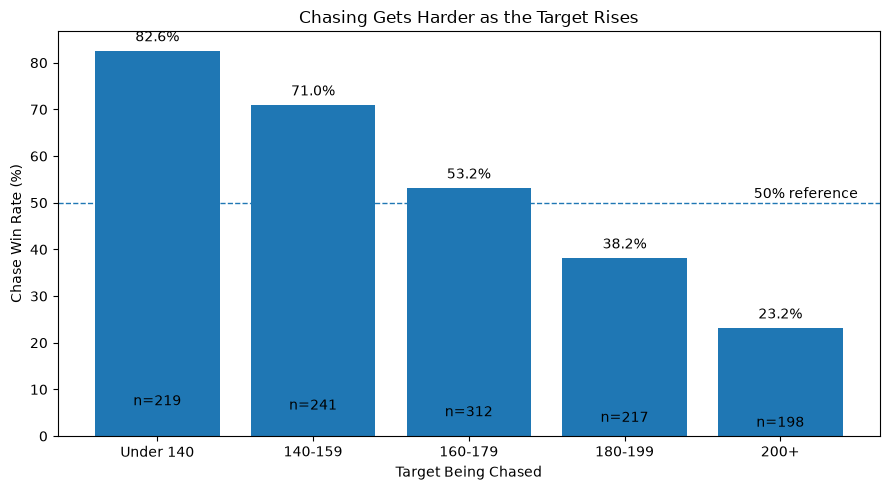

In [126]:
# ============================================
# H2 - Create chart
# ============================================

df = h2_df.copy()

bands = df["target_band"]
rates = df["chase_win_rate_pct"]
counts = df["n_matches"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(bands, rates)

ax.set_title(
    "Chasing Gets Harder as the Target Rises"
)

ax.set_xlabel(
    "Target Being Chased"
)

ax.set_ylabel(
    "Chase Win Rate (%)"
)

# 50% reference
ax.axhline(
    50,
    linestyle="--",
    linewidth=1
)

ax.text(
    len(bands) - 0.5,
    51,
    "50% reference",
    ha="right"
)

# Add values and sample sizes
for bar, rate, n in zip(bars, rates, counts):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 2,
        f"{rate:.1f}%",
        ha="center"
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(2, rate * 0.08),
        f"n={int(n)}",
        ha="center"
    )

fig.tight_layout()

fig.savefig(
    FIG_DIR / "chase_win_rate_target_band.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

# Chart 2 — C1: Runs and Wickets by Innings Phase

**Finding:** Run scoring and wicket risk increase during the Death overs.

In [127]:
# ============================================
# C1 - Runs and wickets by innings phase
# ============================================

c1_query = """
SELECT
    phase,

    ROUND(
        6.0 * SUM(total_runs) / SUM(is_legal),
        2
    ) AS runs_per_over,

    ROUND(
        100.0 * SUM(bowler_wicket) / SUM(is_legal),
        2
    ) AS wickets_per_100_balls,

    SUM(is_legal) AS legal_balls

FROM v_ball

GROUP BY phase

ORDER BY
    CASE phase
        WHEN 'Powerplay' THEN 1
        WHEN 'Middle' THEN 2
        WHEN 'Death' THEN 3
    END;
"""

c1_df = pd.read_sql_query(c1_query, conn)

c1_df

,phase,runs_per_over,wickets_per_100_balls,legal_balls
0,Powerplay,8.03,3.78,86921
1,Middle,7.92,4.07,128191
2,Death,10.04,7.42,62205


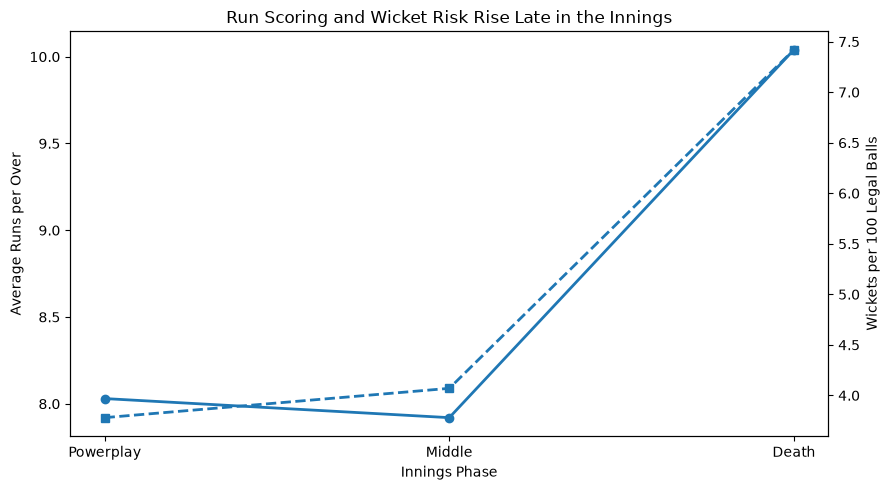

In [128]:
# ============================================
# C1 - Create chart
# ============================================

df = c1_df.copy()

phase = df["phase"]
runs = df["runs_per_over"]
wicket_rate = df["wickets_per_100_balls"]

fig, ax1 = plt.subplots(figsize=(9, 5))

# Runs
ax1.plot(
    phase,
    runs,
    marker="o",
    linewidth=2
)

ax1.set_xlabel(
    "Innings Phase"
)

ax1.set_ylabel(
    "Average Runs per Over"
)

# Wickets
ax2 = ax1.twinx()

ax2.plot(
    phase,
    wicket_rate,
    marker="s",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel(
    "Wickets per 100 Legal Balls"
)

ax1.set_title(
    "Run Scoring and Wicket Risk Rise Late in the Innings"
)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "runs_wickets_by_phase.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

# Chart 3 — G3: Toss Decision Split

**Finding:** The match result differs between teams choosing to bat and teams choosing to field after winning the toss.

In [129]:
# ============================================
# G3 - Toss decision split
# ============================================

g3_query = """
SELECT
    CASE
        WHEN toss_decision = 'field'
        THEN 'Chose to Field'
        ELSE 'Chose to Bat'
    END AS group_label,

    COUNT(*) AS n_matches,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN toss_winner = match_winner
                THEN 1.0
                ELSE 0.0
            END
        ),
        1
    ) AS win_rate_pct

FROM matches

WHERE result = 'win'

GROUP BY
    CASE
        WHEN toss_decision = 'field'
        THEN 'Chose to Field'
        ELSE 'Chose to Bat'
    END

ORDER BY win_rate_pct DESC;
"""

g3_df = pd.read_sql_query(g3_query, conn)

g3_df

,group_label,n_matches,win_rate_pct
0,Chose to Field,785,54.6
1,Chose to Bat,402,45.8


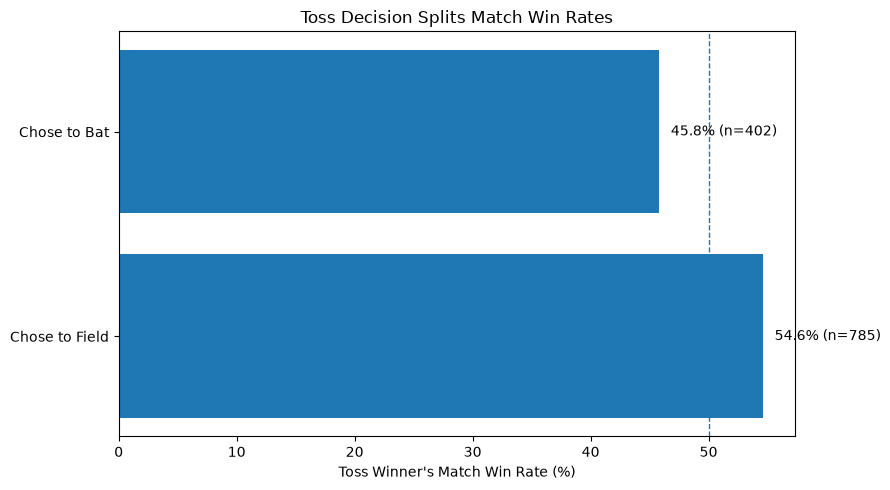

In [130]:
# ============================================
# G3 - Create chart
# ============================================

df = g3_df.copy()

labels = df["group_label"]
rates = df["win_rate_pct"]
counts = df["n_matches"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    labels,
    rates
)

# 50% reference
ax.axvline(
    50,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Toss Decision Splits Match Win Rates"
)

ax.set_xlabel(
    "Toss Winner's Match Win Rate (%)"
)

for bar, rate, n in zip(
    bars,
    rates,
    counts
):

    ax.text(
        rate + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% (n={int(n)})",
        va="center"
    )

fig.tight_layout()

fig.savefig(
    FIG_DIR / "toss_split.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

# Chart 4 — I1: Venue Names Before and After Cleaning

**Finding:** Raw venue names can split the same ground into multiple labels, while cleaning combines spelling variants.

In [131]:
# ============================================
# I1 - Raw venue names
# ============================================

i1_raw_query = """
SELECT
    venue,
    COUNT(DISTINCT match_id) AS matches
FROM matches
WHERE venue IS NOT NULL
GROUP BY venue
ORDER BY matches DESC
LIMIT 10;
"""

i1_raw_df = pd.read_sql_query(
    i1_raw_query,
    conn
)

i1_raw_df

,venue,matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",57
5,"Rajiv Gandhi International Stadium, Uppal",49
6,"MA Chidambaram Stadium, Chepauk",48
7,Sawai Mansingh Stadium,47
8,Dubai International Cricket Stadium,46
9,"MA Chidambaram Stadium, Chepauk, Chennai",38


In [132]:
# ============================================
# I1 - Cleaned venue names
# ============================================

i1_clean_query = """
SELECT
    venue_clean,
    COUNT(DISTINCT match_id) AS matches
FROM v_matches_clean
WHERE venue_clean IS NOT NULL
GROUP BY venue_clean
ORDER BY matches DESC
LIMIT 10;
"""

i1_clean_df = pd.read_sql_query(
    i1_clean_query,
    conn
)

i1_clean_df

,venue_clean,matches
0,Wankhede Stadium,130
1,M Chinnaswamy Stadium,104
2,Eden Gardens,104
3,MA Chidambaram Stadium,95
4,Rajiv Gandhi International Stadium,87
5,Sawai Mansingh Stadium,66
6,Feroz Shah Kotla,60
7,Dubai International Cricket Stadium,46
8,Arun Jaitley Stadium,41
9,Narendra Modi Stadium,37


In [133]:
# ============================================
# I1 - Count unique raw and cleaned venues
# ============================================

raw_count = pd.read_sql_query(
    """
    SELECT COUNT(DISTINCT venue) AS unique_raw_venues
    FROM matches
    WHERE venue IS NOT NULL;
    """,
    conn
)

clean_count = pd.read_sql_query(
    """
    SELECT COUNT(DISTINCT venue_clean) AS unique_cleaned_venues
    FROM v_matches_clean
    WHERE venue_clean IS NOT NULL;
    """,
    conn
)

print(
    "Unique raw venues:",
    int(raw_count.loc[0, "unique_raw_venues"])
)

print(
    "Unique cleaned venues:",
    int(clean_count.loc[0, "unique_cleaned_venues"])
)

Unique raw venues: 59
Unique cleaned venues: 41


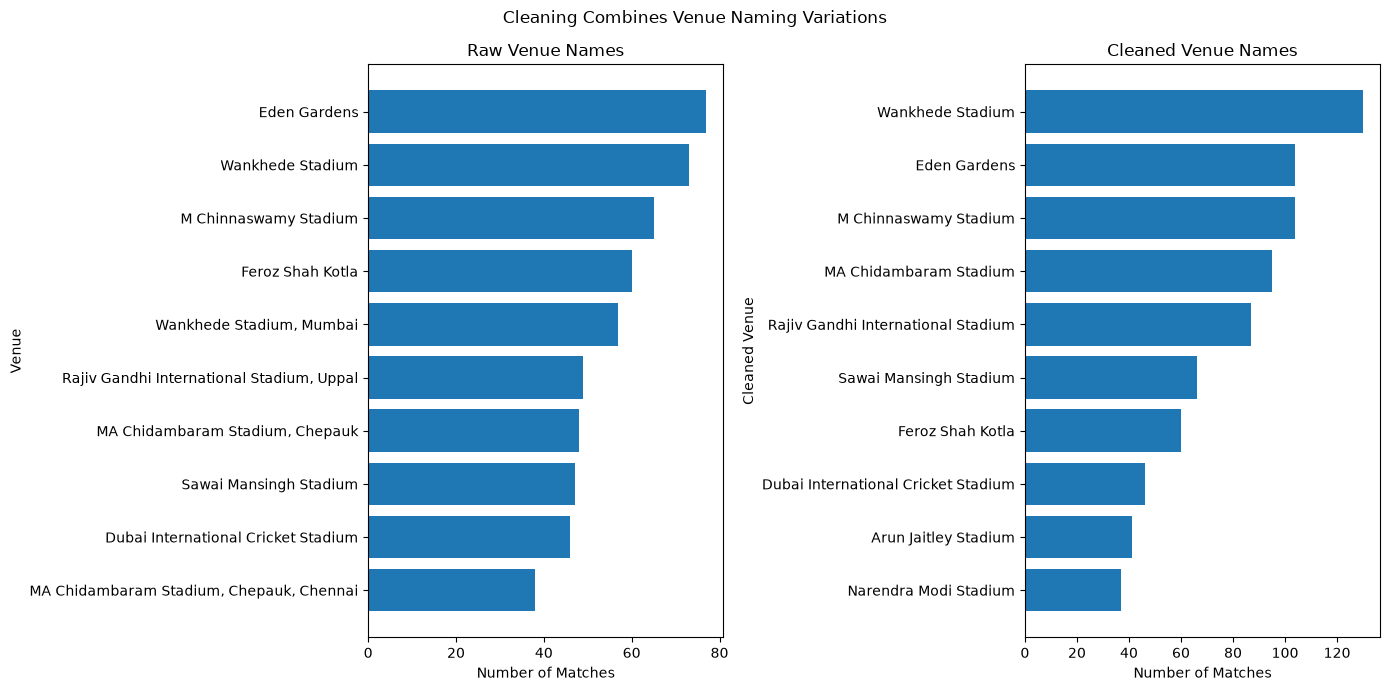

In [134]:
# ============================================
# I1 - Before vs After Cleaning Chart
# ============================================

raw = i1_raw_df.sort_values("matches")
clean = i1_clean_df.sort_values("matches")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

# Raw venues
axes[0].barh(
    raw["venue"],
    raw["matches"]
)

axes[0].set_title(
    "Raw Venue Names"
)

axes[0].set_xlabel(
    "Number of Matches"
)

axes[0].set_ylabel(
    "Venue"
)

# Cleaned venues
axes[1].barh(
    clean["venue_clean"],
    clean["matches"]
)

axes[1].set_title(
    "Cleaned Venue Names"
)

axes[1].set_xlabel(
    "Number of Matches"
)

axes[1].set_ylabel(
    "Cleaned Venue"
)

fig.suptitle(
    "Cleaning Combines Venue Naming Variations"
)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "venue_before_after.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

In [135]:
# ============================================
# Chart file validation
# ============================================

required_charts = [
    "chase_win_rate_target_band.png",
    "runs_wickets_by_phase.png",
    "toss_split.png",
    "venue_before_after.png"
]

for chart in required_charts:

    chart_path = FIG_DIR / chart

    if chart_path.exists():
        print("✓", chart)

    else:
        print("✗ MISSING:", chart)

✓ chase_win_rate_target_band.png
✓ runs_wickets_by_phase.png
✓ toss_split.png
✓ venue_before_after.png


# Chart 5 — Specialism Finding

The fifth chart will use a finding from my assigned specialism area.

Finding:
Population:
Decision:
Doubt:

In [136]:
# ============================================
# CHART 5 - SPECIALISM
# ============================================

# Replace this section with the SQL result
# from your assigned specialism.

# Example:
#
# specialism_df = pd.read_sql_query(
#     specialism_query,
#     conn
# )
#
# Then create the appropriate chart.

In [137]:
# ============================================
# Create Analysis Report
# ============================================

REPORT_PATH = Path("../reports/analysis_report.md")

report_text = """
# IPL Cricket Analytics — Analysis Report

## Three Findings I Am Least Confident About

1. H2 — Chase win rate by target band
2. G3 — Toss decision split
3. I1 — Venue cleaning effect

---

## Scenario H2

**Question:** Does chase success change by target band?

**Number:** Chase win rate varies across the target bands.

**Population:** Completed IPL matches with a recorded first-innings total and defined chase result.

**Decision:** Higher targets should be treated as more difficult chasing situations.

**Doubt:** Target difficulty can also depend on venue, team strength, season and match conditions. Step 4 should test these effects.

![Chase win rate by target band](figures/chase_win_rate_target_band.png)

---

## Scenario C1

**Question:** How do scoring rate and wicket risk change across innings phases?

**Number:** Runs per over and wickets per 100 legal balls are compared across Powerplay, Middle and Death phases.

**Population:** Legal deliveries included in the phase analysis.

**Decision:** Teams may need different batting and bowling approaches in the Death phase.

**Doubt:** Phase differences can be affected by batting order, match situation and team quality.

![Runs and wickets by phase](figures/runs_wickets_by_phase.png)

---

## Scenario G3

**Question:** Does the toss decision relate to match win rate?

**Number:** Match win rate is compared between toss winners who chose to bat and those who chose to field.

**Population:** Completed matches with a recorded toss decision and match winner.

**Decision:** Toss strategy can be considered alongside the match context rather than looking only at who won the toss.

**Doubt:** The relationship is observational and may be affected by venue, season, team strength and match conditions.

![Toss split](figures/toss_split.png)

---

## Scenario I1

**Question:** Does venue cleaning change the apparent venue leaderboard?

**Number:** Raw venue names are compared with cleaned venue names.

**Population:** IPL matches with a recorded venue.

**Decision:** Cleaned venue names should be used when comparing venues.

**Doubt:** Cleaning depends on the mapping rules used to combine venue names.

![Venue before and after cleaning](figures/venue_before_after.png)

---

## Scenario Specialism

**Question:** 

**Number:** 

**Population:** 

**Decision:** 

**Doubt:** 

---

## Final Note

The findings are descriptive. Further statistical validation should be used before treating the observed relationships as causal or universally predictive.
"""

REPORT_PATH.write_text(
    report_text,
    encoding="utf-8"
)

print("Analysis report created:")
print(REPORT_PATH)

Analysis report created:
..\reports\analysis_report.md


# Final Quality Check

Before submission, verify:

- M9 ranking completed
- M9 tested with another team
- Five findings selected
- Five charts created
- Every chart has a finding-based title
- Every chart shows sample size
- Every chart has readable axis labels
- Reference lines used where meaningful
- Charts saved inside reports/figures/
- Analysis Report completed
- Three least-confident findings listed
- Specialism chart completed

# Git Checkpoint

After checking all files, use the VS Code terminal to commit the work.